In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_ollama import ChatOllama
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import (
    DuckDuckGoSearchRun,
    PubmedQueryRun
)
from langchain_community.utilities import (
    DuckDuckGoSearchAPIWrapper,
    PubMedAPIWrapper
)
from langchain_core.tools import tool

import requests
import os
from datetime import datetime, date
from langchain_core.messages import ToolMessage
from langchain_community.tools import YouTubeSearchTool

C:\Users\BJIT\AppData\Local\Temp\ipykernel_3508\20100935.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import (


In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [3]:
load_dotenv(override=True)

True

In [4]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    thinking_level="low",
    temperature=0.4,
    max_output_tokens=512
)

In [5]:
# Buit in Tools

# DuckDuckGo Search
search_tool = DuckDuckGoSearchRun(
    api_wrapper=DuckDuckGoSearchAPIWrapper(
        region="wt-wt",
        max_results=3
    )
)


youtube_tool = YouTubeSearchTool()




# PubMed
pubmed_tool = PubmedQueryRun(
    api_wrapper=PubMedAPIWrapper(
        top_k_results=1,
        doc_content_chars_max=1200
    )
)

In [6]:
@tool
def calculate_age(birth_date: str) -> dict:
    """
    Calculate age from a birth date.
    Birth date format: YYYY-MM-DD
    """
    try:
        birth = datetime.strptime(birth_date, "%Y-%m-%d").date()
        today = date.today()

        if birth > today:
            return {"error": "Birth date cannot be in the future"}

        age = today.year - birth.year

        if (today.month, today.day) < (birth.month, birth.day):
            age -= 1

        return {
            "birth_date": birth_date,
            "current_date": str(today),
            "age": age
        }

    except ValueError:
        return {"error": "Invalid date format. Use YYYY-MM-DD"}

    except Exception as e:
        return {"error": str(e)}

In [7]:
@tool
def get_weather(city: str) -> dict:
    """
    Get the current weather for a city.

    Example cities:
    Dhaka
    London
    New York
    Tokyo

    Use this tool whenever the user asks about
    current weather, temperature, humidity,
    feels-like temperature, or wind speed.
    """

    try:

        # ----------------------------
        # Step 1: Find city coordinates
        # ----------------------------

        geo_url = (
            "https://geocoding-api.open-meteo.com/v1/search"
        )

        geo_response = requests.get(
            geo_url,
            params={
                "name": city,
                "count": 1,
                "language": "en"
            },
            timeout=10
        )

        geo_data = geo_response.json()

        if not geo_data.get("results"):

            return {
                "error": f"City '{city}' not found."
            }

        location = geo_data["results"][0]

        latitude = location["latitude"]
        longitude = location["longitude"]


        # ----------------------------
        # Step 2: Get current weather
        # ----------------------------

        weather_url = (
            "https://api.open-meteo.com/v1/forecast"
        )

        weather_response = requests.get(
            weather_url,
            params={
                "latitude": latitude,
                "longitude": longitude,
                "current": (
                    "temperature_2m,"
                    "apparent_temperature,"
                    "relative_humidity_2m,"
                    "wind_speed_10m"
                )
            },
            timeout=10
        )

        weather_data = weather_response.json()

        current = weather_data["current"]

        return {

            "city": location["name"],

            "country": location.get(
                "country",
                ""
            ),

            "temperature_c":
                current["temperature_2m"],

            "feels_like_c":
                current["apparent_temperature"],

            "humidity_percent":
                current["relative_humidity_2m"],

            "wind_speed_kmh":
                current["wind_speed_10m"]
        }


    except Exception as e:

        return {
            "error": str(e)
        }

In [8]:
print(
    calculate_age.invoke(
        {
            "birth_date": "2001-04-14"
        }
    )
)

{'birth_date': '2001-04-14', 'current_date': '2026-09-17', 'age': 25}


In [9]:
print(
    get_weather.invoke(
        {
            "city": "Beijing"
        }
    )
)

{'city': 'Beijing', 'country': 'China', 'temperature_c': 31.0, 'feels_like_c': 30.9, 'humidity_percent': 33, 'wind_speed_kmh': 6.4}


In [10]:
print(
    search_tool.invoke(
        "latest artificial intelligence news"
    )
)

Explore the latest artificial intelligence news with Reuters - from AI breakthroughs and technology trends to regulation, ethics, business and global impact. Artificial Intelligence News. Everything on AI including futuristic robots with artificial intelligence, computer models of human intelligence and more. AI News delivers the latest updates in artificial intelligence, machine learning, deep learning, enterprise AI, and emerging tech worldwide.


In [11]:
print(
    pubmed_tool.invoke(
        "Alzheimer disease MRI"
    )
)

PMID: 42749078
Published: 2026-09-16
Title: Adaptive hypergraph learning reveals high-order functional network alterations in mild cognitive impairment.
Copyright Information: Copyright © 2026. Published by Elsevier Inc.
Summary::
Mild cognitive impairment (MCI) is an important prodromal stage of Alzheimer's disease, and its early identification is critical for risk assessment and timely intervention. Resting-state functional magnetic resonance imaging (rs-fMRI) can noninvasively characterize brain functional activity and connectivity. However, most existing methods rely on static second-order functional connectivity, limiting their ability to capture dynamic coordination and high-order interactions among multiple brain regions. To address these limitations, we propose a brain functional network analysis framework integrating multi-scale temporal feature fusion with adaptive high-order hypergraph convolution. Specifically, the multi-scale temporal fusion module captures functional dyna

In [12]:
print(
    youtube_tool.invoke(
        "LangGraph tutorial,3"
    )
)

['https://www.youtube.com/watch?v=jGg_1h0qzaM&pp=ygUSTGFuZ0dyYXBoIHR1dG9yaWFs', 'https://www.youtube.com/watch?v=uWLJAtMOVT0&t=213s&pp=ygUSTGFuZ0dyYXBoIHR1dG9yaWFs0gcJCSQMAYcqIYzv', 'https://www.youtube.com/watch?v=DtW_Lc9hYoU&pp=ygUSTGFuZ0dyYXBoIHR1dG9yaWFs']


In [13]:

tools = [
    search_tool,
    youtube_tool,
    pubmed_tool,
    calculate_age,
    get_weather
]


llm_with_tools = llm.bind_tools(tools)

In [14]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [15]:
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


tool_node = ToolNode(tools)  

In [16]:
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [17]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges(
    "chat_node",
    tools_condition
)

graph.add_edge(
    "tools",
    "chat_node"
)

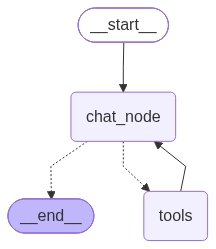

In [18]:
chatbot = graph.compile()

chatbot

In [19]:
def check_tool_usage(out):

    tool_used = False

    for message in out["messages"]:

        if hasattr(message, "tool_calls") and message.tool_calls:

            tool_used = True

            for tool_call in message.tool_calls:

                print("Tool used:", tool_call["name"])
                print("Arguments:", tool_call["args"])

    if not tool_used:

        print("No tool used - LLM answered by itself.")

In [20]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="Hello my name is Farhan who are you and what can you do for me?"
        )
    ]
})

check_tool_usage(out)
print(f"Final State: {out}")

#print(f"Tool Response: {out['messages'][-2].content}")

print(f" AI Response: {out['messages'][-1].content[0]['text']}")





c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


No tool used - LLM answered by itself.
Final State: {'messages': [HumanMessage(content='Hello my name is Farhan who are you and what can you do for me?', additional_kwargs={}, response_metadata={}, id='8132e6e2-a6be-40b0-b6ce-1da6a6246c71'), AIMessage(content=[{'type': 'text', 'text': "Hello Farhan! It's nice to meet you. \n\nI am an AI assistant, designed to help you with a wide variety of tasks. Think of me as a virtual research assistant, a brainstorming partner, a tutor, or a handy companion for your day-to-day needs. \n\nHere are some of the things I can do for you:\n\n* **Answer Questions:** Whether it's about history, science, pop culture, or general trivia, I can find and explain information for you.\n* **Writing & Editing:** I can help you write emails, essays, stories, resumes, or cover letters, and proofread or improve text you've already written.\n* **Coding & Tech Support:** I can write, debug, and explain code in various programming languages (like Python, JavaScript, C++

In [21]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="What is the weather in London?"
        )
    ]
})


check_tool_usage(out)
print(f"Final State: {out}")

print(f"Tool Response: {out['messages'][-2].content}")

print(f" AI Response: {out['messages'][-1].content[0]['text']}")




c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Tool used: get_weather
Arguments: {'city': 'London'}
Final State: {'messages': [HumanMessage(content='What is the weather in London?', additional_kwargs={}, response_metadata={}, id='9ca8a89e-5bb4-4136-b0a2-30ff491fd9fe'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "London"}'}, '__gemini_function_call_thought_signatures__': {'call_689590': 'El4KXAERTTIPcBmyIoZtBjY5qusDBeDwFET1ByC93BdkOMdA8yByYV6zKeoMNsN5j50xLPyTMKI+pfzsw5sl3yHnGmlMyUhRqmYOs91HaVxlsdm9ftuqjQrDkNbGBBum'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0ae6c-347f-72e0-975d-e226ae17d829-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'London'}, 'id': 'call_689590', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 400, 'output_tokens': 16, 'total_tokens': 416, 'input_token_details': {'cache_read': 0}}), ToolMessage(con

In [22]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="How old is someone born on 2000-05-20?"
        )
    ]
})

check_tool_usage(out)
print(f"Final State: {out}")

print(f"Tool Response: {out['messages'][-2].content}")

print(f" AI Response: {out['messages'][-1].content[0]['text']}")

c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Tool used: calculate_age
Arguments: {'birth_date': '2000-05-20'}
Final State: {'messages': [HumanMessage(content='How old is someone born on 2000-05-20?', additional_kwargs={}, response_metadata={}, id='d49a4d0a-9e00-4fe6-b585-ef8e553861be'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'calculate_age', 'arguments': '{"birth_date": "2000-05-20"}'}, '__gemini_function_call_thought_signatures__': {'call_759654': 'El4KXAERTTIPsDeig5AuJeaetetWHJo3Zq0bxh5+KdPe3kz3/SDM8eHipQYOh5iDd8KZcXu4HVwx6W8obv42R54hCJfTvH5PUa74TpqCSiPU1NrD1/upeYA4jvAVka8s'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0ae6c-42dc-7913-86c6-25360af9351e-0', tool_calls=[{'name': 'calculate_age', 'args': {'birth_date': '2000-05-20'}, 'id': 'call_759654', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 411, 'output_tokens': 27, 'total_tokens': 438, 'input_token_de

In [23]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="Find some recent medical research about diabetes."
        )
    ]
})

check_tool_usage(out)
print(f"Final State: {out}")

print(f"Tool Response: {out['messages'][-2].content}")

print(f" AI Response: {out['messages'][-1].content[0]['text']}")

c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Tool used: pub_med
Arguments: {'query': 'diabetes recent research 2023 2024'}
Tool used: pub_med
Arguments: {'query': 'type 2 diabetes breakthrough treatment 2024'}
Final State: {'messages': [HumanMessage(content='Find some recent medical research about diabetes.', additional_kwargs={}, response_metadata={}, id='ef581500-f57d-481a-88c0-4da7975453a4'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'pub_med', 'arguments': '{"query": "diabetes recent research 2023 2024"}'}, '__gemini_function_call_thought_signatures__': {'call_507837': 'El4KXAERTTIPDifvoYGZgPgUya4S92ZWsBHh8cZ/Gn0+nr9AbC0XxpnmC8u5KKYcUXxlK4fbvPx/ZvKWymJDqvrXDhQowV/FOKS4RgDE9BmEH2JKXwSxbrwnswhML06k'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0ae6c-48f0-7b12-a8be-4918992d48d2-0', tool_calls=[{'name': 'pub_med', 'args': {'query': 'diabetes recent research 2023 2024'}, 'id': 'call_507837', 'ty

In [24]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="Find me 3 YouTube video tutorials about Transformer models."
        )
    ]
})

check_tool_usage(out)
print(f"Final State: {out}")

print(f"Tool Response: {out['messages'][-2].content}")

print(f" AI Response: {out['messages'][-1].content[0]['text']}")

c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Tool used: youtube_search
Arguments: {'query': 'Transformer models tutorial, 3'}
Final State: {'messages': [HumanMessage(content='Find me 3 YouTube video tutorials about Transformer models.', additional_kwargs={}, response_metadata={}, id='04d3fb5d-c06b-4a7d-9384-16afd91a770f'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'youtube_search', 'arguments': '{"query": "Transformer models tutorial, 3"}'}, '__gemini_function_call_thought_signatures__': {'call_642142': 'El4KXAERTTIPGP7WOQz5TTB8N+mP0hOD8Vd/R3AXsrQyEYar6oUHVi1Nc0kRhGZ+JwczF64/5SQDZM1Fvrlt11ud5JmpsE47tj+OEgrlVNpkBwdFlLn9kIaKh5WLvOrx'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0ae6c-6863-7ff1-b526-29547db1accb-0', tool_calls=[{'name': 'youtube_search', 'args': {'query': 'Transformer models tutorial, 3'}, 'id': 'call_642142', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_to

In [25]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="Tell me about the latest developments in Quantum Computing "
        )
    ]
})

check_tool_usage(out)
print(f"Final State: {out}")

print(f"Tool Response: {out['messages'][-2].content}")

print(f" AI Response: {out['messages'][-1].content[0]['text']}")

c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\BJIT\Desktop\Langgraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Tool used: duckduckgo_search
Arguments: {'query': 'latest developments in quantum computing 2024 2025'}
Final State: {'messages': [HumanMessage(content='Tell me about the latest developments in Quantum Computing ', additional_kwargs={}, response_metadata={}, id='dac6de0f-0ba5-484d-9203-55a40eb91ebf'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duckduckgo_search', 'arguments': '{"query": "latest developments in quantum computing 2024 2025"}'}, '__gemini_function_call_thought_signatures__': {'call_692485': 'El4KXAERTTIPO0yMk8BNLSe7BXLZJd/L0VUip4HzgV4f38YdMxeFN4LR2pVHevT1M8j1sPSU1HFdAN/B49r7TDnx5YY0sw7e8rWW32ATCTofQ0pbCAUz2OI8Y/l+1eiT'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0ae6c-7755-7283-a3a3-01ddc25de9cd-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest developments in quantum computing 2024 2025'}, 'id': 'call_692485', 't